In [1]:
import json
import numpy as np

In [2]:
#let's load the model weights and see which models has nan values in the 
import numpy as np
import json

# Load your doc2topic_weights for bertopic
with open('../output/topic_models/bertopic_bill_200.json') as f:
    model_data = json.load(f)

# Adjust the key if needed
doc2topic = np.array(model_data['doc2topic_dist'])  # shape: (num_docs, num_topics)

# Check for zero-sum columns (topics)
zero_sum_topics = []
for t_id in range(doc2topic.shape[1]):
    topic_weights = doc2topic[:, t_id]
    s = topic_weights.sum()
    if s == 0:
        zero_sum_topics.append(t_id)
    elif np.isnan(s):
        print(f"NaN encountered in topic {t_id}")

print(f"Topics with zero total weight: {zero_sum_topics}")
print(f"Total topics: {doc2topic.shape[1]}")

import numpy as np

# Assuming doc2topic_dist is already loaded as a numpy array
has_nan = np.isnan(doc2topic).any()
nan_indices = np.argwhere(np.isnan(doc2topic))

print(f"Does doc2topic_dist have any NaN values? {has_nan}")
if has_nan:
    print(f"Indices of NaN values: {nan_indices}")

# Check for rows (documents) with sum zero
row_sums = np.sum(doc2topic, axis=1)
zero_sum_docs = np.where(row_sums == 0)[0]

print(f"Documents with zero total topic weight: {zero_sum_docs}")
print(f"Total documents: {doc2topic.shape[0]}")
print(f"Number of documents with zero topic weight: {len(zero_sum_docs)}")

Topics with zero total weight: []
Total topics: 200
Does doc2topic_dist have any NaN values? False
Documents with zero total topic weight: [  144   167   170   255   324   332   445   489   493   597   599   846
   889  1077  1397  1804  1807  1832  2842  3052  3063  3124  3236  3328
  3355  3430  3652  3668  3795  3985  4231  4392  4395  4586  4664  4735
  5129  5132  5165  5304  5327  5384  5402  5421  5487  5521  5650  5690
  5694  5847  5917  5929  5967  6001  6067  6142  6188  6306  6376  6520
  6552  6581  6622  6634  6658  6659  6727  6798  6961  7130  7350  7621
  8533  8665  8913  8987  9040  9121  9208  9213  9461  9659  9682 10065
 10066 10404 10432 10447 10484 10698 10719 10852 10891 10905 11032 11039
 11097 11227 11408 11447 11456 11468 11600 11741 11779 11784 12612 12631
 12639 12657 12718 12756 12767 12776 12793 12801 12834 12922 12944 12952
 12986 13003 13103 13165 13198 13315 13394 13546 13551 13566 13597 13665
 13719 13761 13766 13862 13891 13917 13920 13956 14055 140

Does doc2topic_dist have any NaN values? False


In [2]:
saved_topic_model = '../output/topic_models/lda_wikitext_25.json'
with open(saved_topic_model, 'r') as fp:
    saved_weights = json.load(fp)


In [31]:
doc2topic_dist.shape

(14290, 25)

In [34]:
topic_labels = np.argmax(doc2topic_dist, axis=1)
topic_labels


array([24,  3,  3, ..., 21, 20, 19])

In [39]:
topic_doc_ids = np.where(topic_labels == 0)[0]
topic_doc_ids.shape

(1206,)

In [4]:
saved_weights.keys()

dict_keys(['topic2word_dist', 'doc2topic_dist', 'topic2doc_dist', 'vocab'])

In [8]:
doc2topic_dist = np.array(saved_weights['doc2topic_dist'])

In [10]:
doc2topic_dist.shape

(14290, 25)

In [ ]:
#let's check whether each column sum up to 1
np.sum(doc2topic_dist, axis=0)

array([1027.25240775,  532.63728196,  522.92035019,  628.44506107,
        608.00411724,  151.96714966,  567.88679812,  180.61290776,
        552.22345898,  616.86256283,  594.44441022,  685.03861743,
        672.25656519,  300.93657886,  487.03870445,  525.87195993,
        520.32259533,  274.66238404,  260.83942408,  609.77265735,
        570.75976135, 1036.64387807,  814.43402535,  384.50947455,
       1163.65693155])

In [25]:
weights_0 = doc2topic_dist[:, 0]
valid_mask_0 = weights_0 > 0
np.sum(valid_mask_0)

14290

In [29]:
valid_mask_0


array([ True,  True,  True, ...,  True,  True,  True])

In [27]:
#let's see the minimum and maximum weights for topic 0
weights_0.min(), weights_0.max()

(8.247997357102577e-06, 0.9826004505157471)

Text(0.5, 1.0, 'Distribution of topic weights for topic 0')

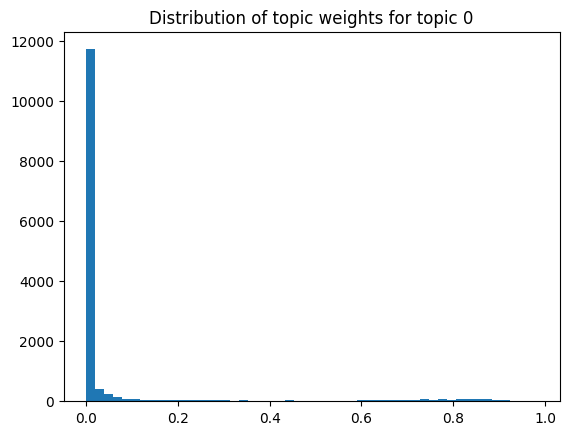

In [26]:
#let's plot the distribution of the weights for topic 0
import matplotlib.pyplot as plt
plt.hist(weights_0, bins=50)
plt.title('Distribution of topic weights for topic 0')

In [21]:
doc2topic_dist.shape

(14290, 25)

In [14]:
np.sum(doc2topic_dist, axis=1).reshape(-1, 1).shape

(14290, 1)

In [16]:
normalized_doc2topic_dist = doc2topic_dist / np.sum(doc2topic_dist, axis=1).reshape(-1, 1)
normalized_doc2topic_dist.shape

(14290, 25)

In [ ]:
np.sum(normalized_doc2topic_dist, axis=1)

(14290,)

In [20]:
len(doc2topic_dist)

14290